In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

In [2]:
modeling_data = pd.read_csv('../data/final_youtube_v2.csv')
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17528 non-null  int64  
 1   views                     17528 non-null  int64  
 2   likes                     17528 non-null  int64  
 3   comments                  17528 non-null  int64  
 4   views_log                 17528 non-null  float64
 5   likes_log                 17528 non-null  float64
 6   comments_log              17528 non-null  float64
 7   likes_log_win             17528 non-null  float64
 8   comments_log_win          17528 non-null  float64
 9   duration_scaled           17528 non-null  float64
 10  framerate_scaled          17528 non-null  float64
 11  bitrate_scaled            17528 non-null  float64
 12  views_log_scaled          17528 non-null  float64
 13  likes_log_scaled          17528 non-null  float64
 14  commen

In [3]:
cat_columns = [col for col in modeling_data.columns if col.startswith('cat_')]

for col in cat_columns:
    modeling_data[col] = modeling_data[col].astype(int)

print(f"✅ Converted {len(cat_columns)} category columns to int")

print(f"\nData types:")
print(modeling_data[cat_columns].dtypes.value_counts())

✅ Converted 15 category columns to int

Data types:
int64    15
Name: count, dtype: int64


In [4]:
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17528 non-null  int64  
 1   views                     17528 non-null  int64  
 2   likes                     17528 non-null  int64  
 3   comments                  17528 non-null  int64  
 4   views_log                 17528 non-null  float64
 5   likes_log                 17528 non-null  float64
 6   comments_log              17528 non-null  float64
 7   likes_log_win             17528 non-null  float64
 8   comments_log_win          17528 non-null  float64
 9   duration_scaled           17528 non-null  float64
 10  framerate_scaled          17528 non-null  float64
 11  bitrate_scaled            17528 non-null  float64
 12  views_log_scaled          17528 non-null  float64
 13  likes_log_scaled          17528 non-null  float64
 14  commen

# Loại bỏ các cột có thể dẫn đến data leakage

In [5]:
leakage_features = [
    'views', 'comments',
    'likes_log_win',

    'likes_log_scaled',
    'likes_log_win_scaled',

    'Unnamed: 0',

]

# Loại bỏ các cột tồn tại
existing_leakage = [col for col in leakage_features if col in modeling_data.columns]
df_clean = modeling_data.drop(columns=existing_leakage, errors='ignore')

print(f"Removed {len(existing_leakage)} leakage features")
print(f"Remaining: {df_clean.shape[1]} columns")

Removed 6 leakage features
Remaining: 43 columns


In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 43 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   likes                     17528 non-null  int64  
 1   views_log                 17528 non-null  float64
 2   likes_log                 17528 non-null  float64
 3   comments_log              17528 non-null  float64
 4   comments_log_win          17528 non-null  float64
 5   duration_scaled           17528 non-null  float64
 6   framerate_scaled          17528 non-null  float64
 7   bitrate_scaled            17528 non-null  float64
 8   views_log_scaled          17528 non-null  float64
 9   comments_log_scaled       17528 non-null  float64
 10  comments_log_win_scaled   17528 non-null  float64
 11  has_description           17528 non-null  int64  
 12  has_hashtags              17528 non-null  int64  
 13  cat_Comedy                17528 non-null  int64  
 14  cat_Ed

# Chuẩn bị data cho huấn luyện

In [7]:
# Target
y = df_clean['likes_log']

# Features
X = df_clean.drop(columns=['likes_log', 'likes'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"Split ratio: 80/20")

X shape: (17528, 41)
y shape: (17528,)
Train set: (14022, 41)
Test set:  (3506, 41)
Split ratio: 80/20


# Tạo pipeline huấn luyện

In [8]:
pipeline = Pipeline([
    ("poly", PolynomialFeatures(
        degree=1,
        interaction_only=True,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)


In [9]:
y_train_pred_log = pipeline.predict(X_train)
y_test_pred_log = pipeline.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

# Đánh giá trên tập kiểm thử và huấn luyện

In [10]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.8070          0.8088
MSE                           0.4723          0.4898
RMSE                          0.6873          0.6999
MAE                           0.5171          0.5242

Overfit (R² diff)            -0.0018
   ✅ Model generalize tốt


# Plot đánh giá

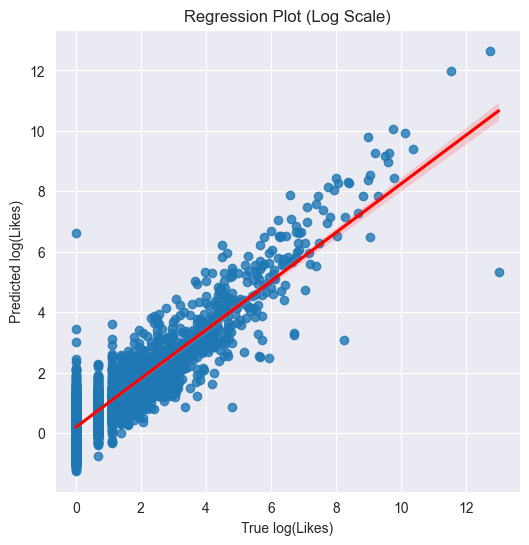

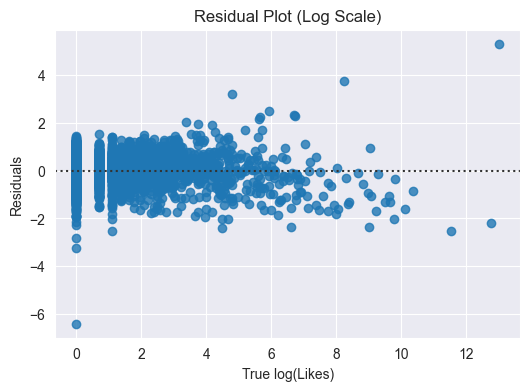

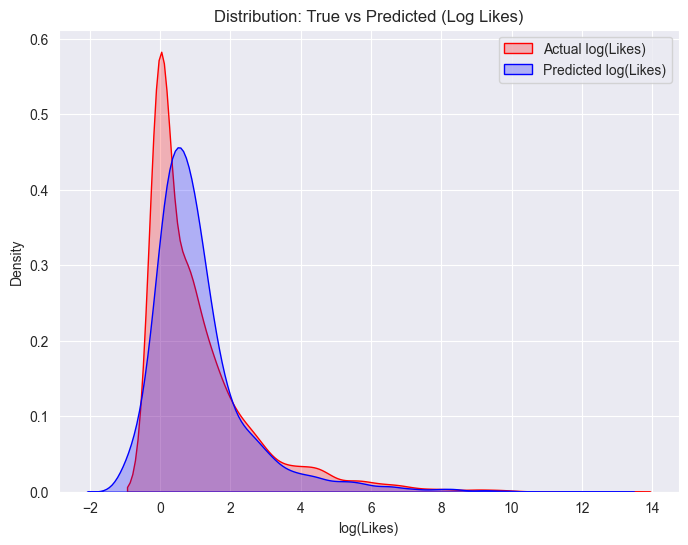

In [11]:
y_true = y_test
y_pred = y_pred
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

# ----- Distribution comparison -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()

# K-Fold CrossValidation

In [12]:
k = 5
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mse_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mae_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')

In [13]:
mse_scores = pd.DataFrame(mse_scores*-1, columns=['MSE'])
rmse_scores = pd.DataFrame(rmse_scores*-1, columns=['RMSE'])
mae_scores = pd.DataFrame(mae_scores*-1, columns=['MAE'])
r2_scores = pd.DataFrame(r2_scores, columns=['R2'])
score = pd.concat([mse_scores, rmse_scores, mae_scores, r2_scores], axis=1)
score

,MSE,RMSE,MAE,R2
0,0.458622,0.677216,0.510756,0.816075
1,0.436388,0.660597,0.505185,0.818319
2,0.510359,0.714394,0.528647,0.801479
3,0.479249,0.692278,0.526217,0.812780
4,0.503394,0.709502,0.526295,0.783380


In [14]:
print(f"Average MSE across {k} folds: {np.mean(mse_scores):.2f}")
print(f"Average RMSE across {k} folds: {np.mean(rmse_scores):.2f}")
print(f"Average MAE across {k} folds: {np.mean(mae_scores):.2f}")
print(f"Average R2 across {k} folds: {np.mean(r2_scores):.2f}")

Average MSE across 5 folds: 0.48
Average RMSE across 5 folds: 0.69
Average MAE across 5 folds: 0.52
Average R2 across 5 folds: 0.81


Metric                              Train                 Test
----------------------------------------------------------------------
R² Score                           0.1864               0.3833
MSE                         53,957,192.29        58,748,654.84
RMSE                             7,345.56             7,664.77
MAE                                130.77               200.25

Overfit (R² diff)                 -0.1969
   ⚠️ Model có dấu hiệu underfit


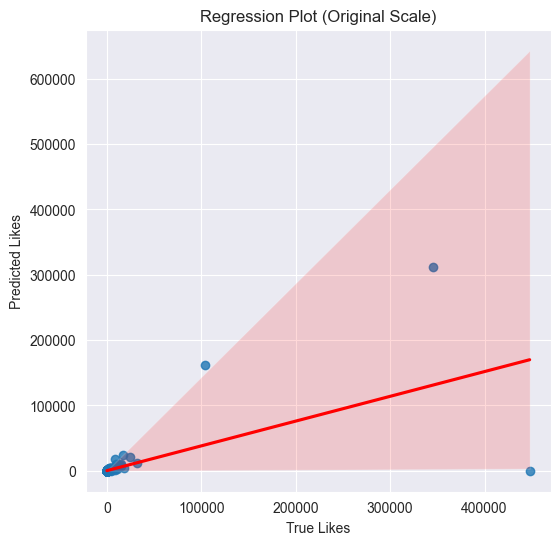

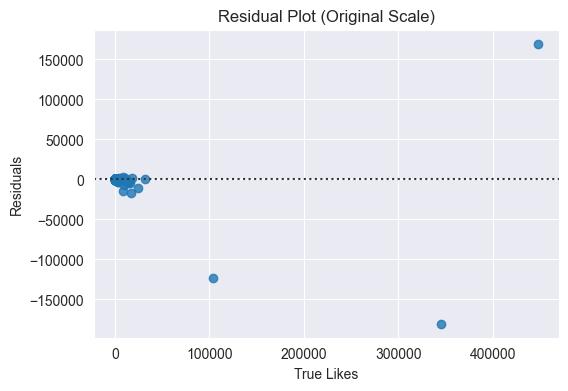

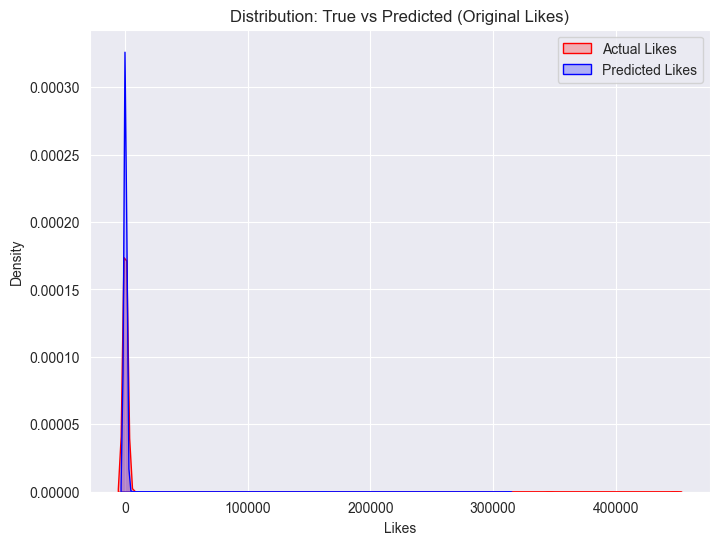

In [15]:
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

r2_train_orig = r2_score(y_train_orig, y_train_pred_orig)
r2_test_orig = r2_score(y_test_orig, y_test_pred_orig)
mse_train_orig = mean_squared_error(y_train_orig, y_train_pred_orig)
mse_test_orig = mean_squared_error(y_test_orig, y_test_pred_orig)
mae_train_orig = mean_absolute_error(y_train_orig, y_train_pred_orig)
mae_test_orig = mean_absolute_error(y_test_orig, y_test_pred_orig)

print(f"{'Metric':<20s} {'Train':>20s} {'Test':>20s}")
print("-" * 70)
print(f"{'R² Score':<20s} {r2_train_orig:>20.4f} {r2_test_orig:>20.4f}")
print(f"{'MSE':<20s} {mse_train_orig:>20,.2f} {mse_test_orig:>20,.2f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_orig):>20,.2f} {np.sqrt(mse_test_orig):>20,.2f}")
print(f"{'MAE':<20s} {mae_train_orig:>20,.2f} {mae_test_orig:>20,.2f}")

overfit = r2_train_orig - r2_test_orig
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>20.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

y_true_orig = y_test_orig
y_pred_orig = y_test_pred_orig
residuals_orig = y_true_orig - y_pred_orig

# ----- 1. Regression plot (Original Scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true_orig, y=y_pred_orig, line_kws={'color':'red'})
plt.xlabel("True Likes")
plt.ylabel("Predicted Likes")
plt.title("Regression Plot (Original Scale)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

# ----- 2. Residual plot (Original Scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true_orig, y=residuals_orig, line_kws={'color':'red'})
plt.xlabel("True Likes")
plt.ylabel("Residuals")
plt.title("Residual Plot (Original Scale)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

# ----- 3. Distribution comparison (Original Scale) -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true_orig, color='red', label='Actual Likes', shade=True)
sns.kdeplot(y_pred_orig, color='blue', label='Predicted Likes', shade=True)
plt.title('Distribution: True vs Predicted (Original Likes)')
plt.xlabel('Likes')
plt.ylabel('Density')
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()

# Thực nghiệm với poly_degree = 2

In [16]:
pipeline2 = Pipeline([
    ("poly", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    )),
    ("linear", LinearRegression())
])

# Fit
pipeline2.fit(X_train, y_train)

# Predict
y_pred = pipeline2.predict(X_test)


In [17]:
y_train_pred_log = pipeline2.predict(X_train)
y_test_pred_log = pipeline2.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

In [18]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.8506          0.8466
MSE                           0.3657          0.3930
RMSE                          0.6048          0.6269
MAE                           0.4408          0.4547

Overfit (R² diff)             0.0040
   ✅ Model generalize tốt


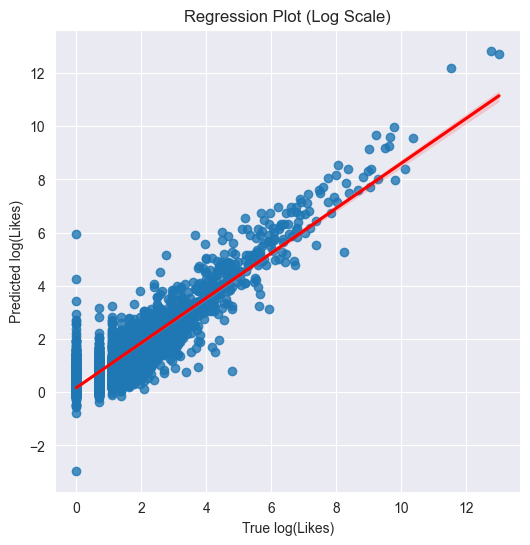

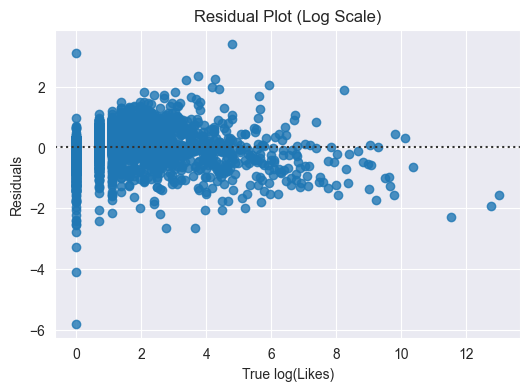

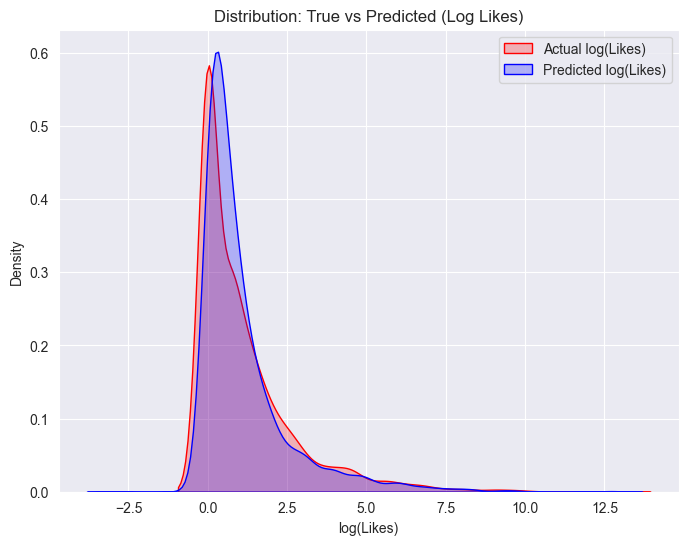

In [19]:
y_true = y_test
y_pred = y_pred
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

# ----- Distribution comparison -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [20]:
k = 5
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mse_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mae_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='r2')

In [21]:
mse_scores = pd.DataFrame(mse_scores*-1, columns=['MSE'])
rmse_scores = pd.DataFrame(rmse_scores*-1, columns=['RMSE'])
mae_scores = pd.DataFrame(mae_scores*-1, columns=['MAE'])
r2_scores = pd.DataFrame(r2_scores, columns=['R2'])
score = pd.concat([mse_scores, rmse_scores, mae_scores, r2_scores], axis=1)
score

,MSE,RMSE,MAE,R2
0,0.375151,0.612496,0.446092,0.849550
1,0.463047,0.680475,0.457436,0.807221
2,0.436897,0.660982,0.463953,0.830054
3,0.411399,0.641404,0.460322,0.839286
4,0.424980,0.651905,0.466469,0.817123


In [22]:
print(f"Average MSE across {k} folds: {np.mean(mse_scores):.2f}")
print(f"Average RMSE across {k} folds: {np.mean(rmse_scores):.2f}")
print(f"Average MAE across {k} folds: {np.mean(mae_scores):.2f}")
print(f"Average R2 across {k} folds: {np.mean(r2_scores):.2f}")

Average MSE across 5 folds: 0.42
Average RMSE across 5 folds: 0.65
Average MAE across 5 folds: 0.46
Average R2 across 5 folds: 0.83


In [23]:
def analyze_feature_importance(model, X, top_n=20):

    # Extract feature names after PolynomialFeatures
    poly = model.named_steps['poly']
    linear = model.named_steps['linear']

    feature_names = poly.get_feature_names_out(X.columns)

    # Extract coefficients
    coef = linear.coef_

    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef,
        'Abs_Coefficient': np.abs(coef)
    }).sort_values('Abs_Coefficient', ascending=False)

    # Print top features
    print(f"\n{'='*80}")
    print(f"TOP {top_n} MOST IMPORTANT FEATURES (by |Coefficient|)")
    print(f"{'='*80}")
    print(feature_importance.head(top_n).to_string(index=False))

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    top_positive = feature_importance.sort_values(
        'Coefficient', ascending=False
    ).head(top_n)

    axes[0].barh(
        top_positive['Feature'][::-1],
        top_positive['Coefficient'][::-1],
        alpha=0.7
    )
    axes[0].set_title(f'Top {top_n} Positive Effects')
    axes[0].set_xlabel('Coefficient Value')

    top_negative = feature_importance.sort_values(
        'Coefficient', ascending=True
    ).head(top_n)

    axes[1].barh(
        top_negative['Feature'][::-1],
        top_negative['Coefficient'][::-1],
        alpha=0.7
    )
    axes[1].set_title(f'Top {top_n} Negative Effects')
    axes[1].set_xlabel('Coefficient Value')

    plt.tight_layout()
    plt.show()

    return feature_importance


TOP 20 MOST IMPORTANT FEATURES (by |Coefficient|)
                Feature  Coefficient  Abs_Coefficient
resolution_score_scaled     1.493700         1.493700
                  is_4k    -0.539827         0.539827
           comments_log     0.419662         0.419662
    comments_log_scaled     0.401552         0.401552
              cat_Shows     0.326446         0.326446
              views_log     0.273317         0.273317
           aspect_ratio     0.157543         0.157543
   cat_Film & Animation     0.151588         0.151588
            is_high_fps     0.117886         0.117886
     cat_People & Blogs     0.117449         0.117449
       views_log_scaled     0.110500         0.110500
              cat_Music     0.109024         0.109024
    cat_Travel & Events    -0.096953         0.096953
    cat_News & Politics    -0.095939         0.095939
comments_log_win_scaled    -0.095354         0.095354
    is_popular_category     0.092379         0.092379
             cat_Sports    -0.0

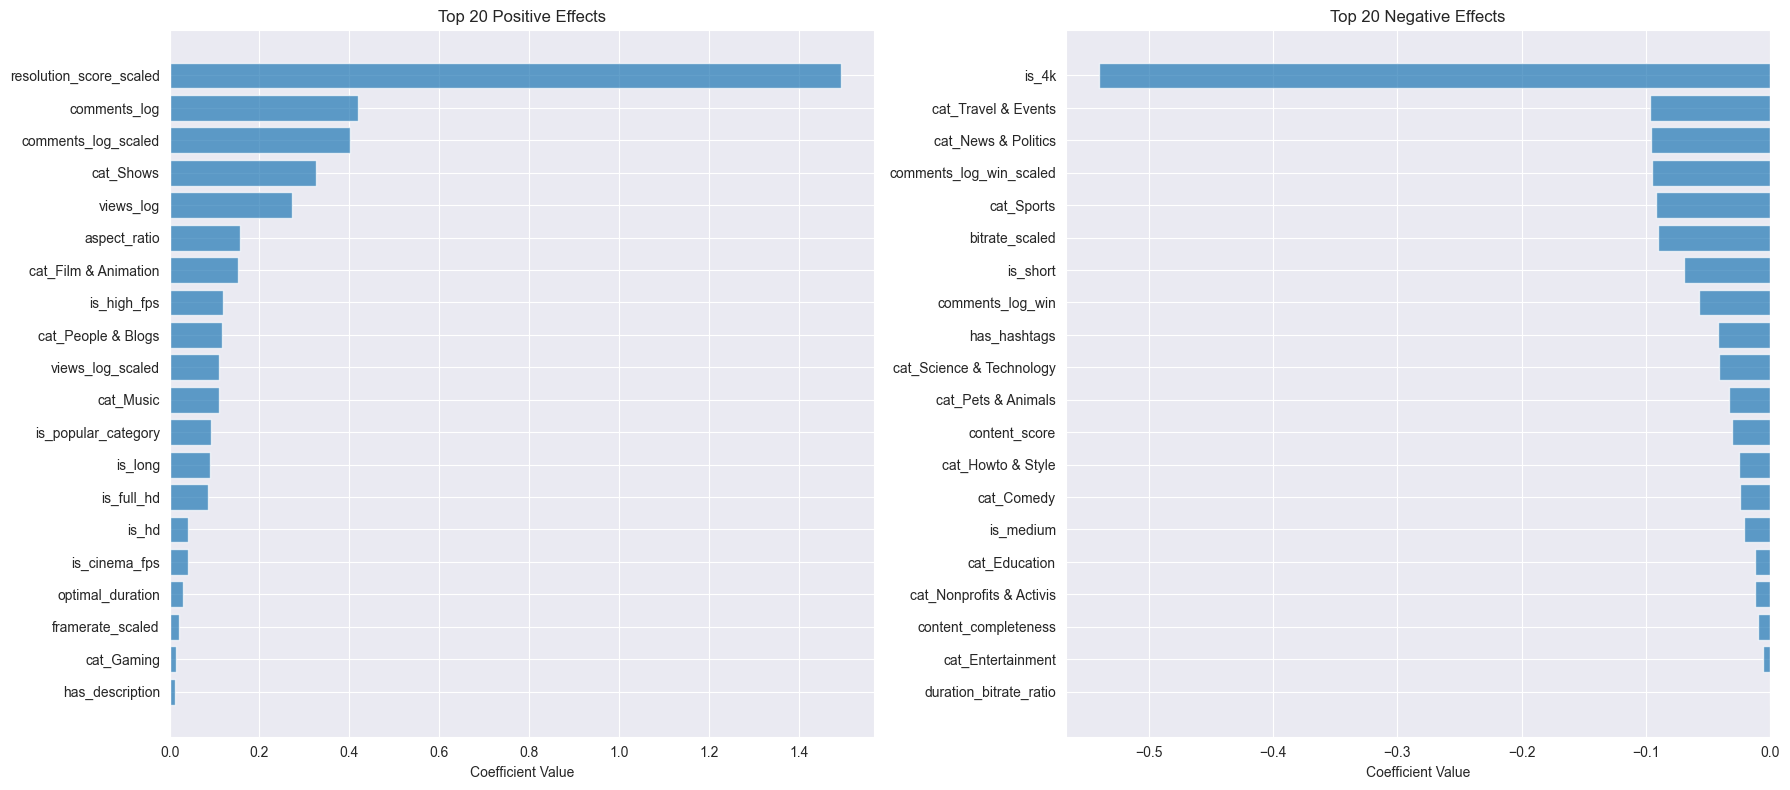

In [24]:
feature_importance = analyze_feature_importance(
    pipeline,
    X_train,
    top_n=20
)


TOP 20 MOST IMPORTANT FEATURES (by |Coefficient|)
                                         Feature  Coefficient  Abs_Coefficient
                          cat_Shows aspect_ratio    18.567657        18.567657
               cat_Shows resolution_score_scaled     7.137160         7.137160
                            cat_Shows is_full_hd     3.032025         3.032025
    cat_Film & Animation resolution_score_scaled     2.560353         2.560353
                             cat_Shows is_medium    -2.553447         2.553447
                       duration_scaled cat_Shows    -2.531471         2.531471
     cat_Travel & Events resolution_score_scaled     1.823399         1.823399
            resolution_score_scaled aspect_ratio    -1.818529         1.818529
                         cat_Shows content_score    -1.773453         1.773453
                               cat_Shows is_long     1.666721         1.666721
                         cat_Shows is_cinema_fps    -1.577209         1.577209
 

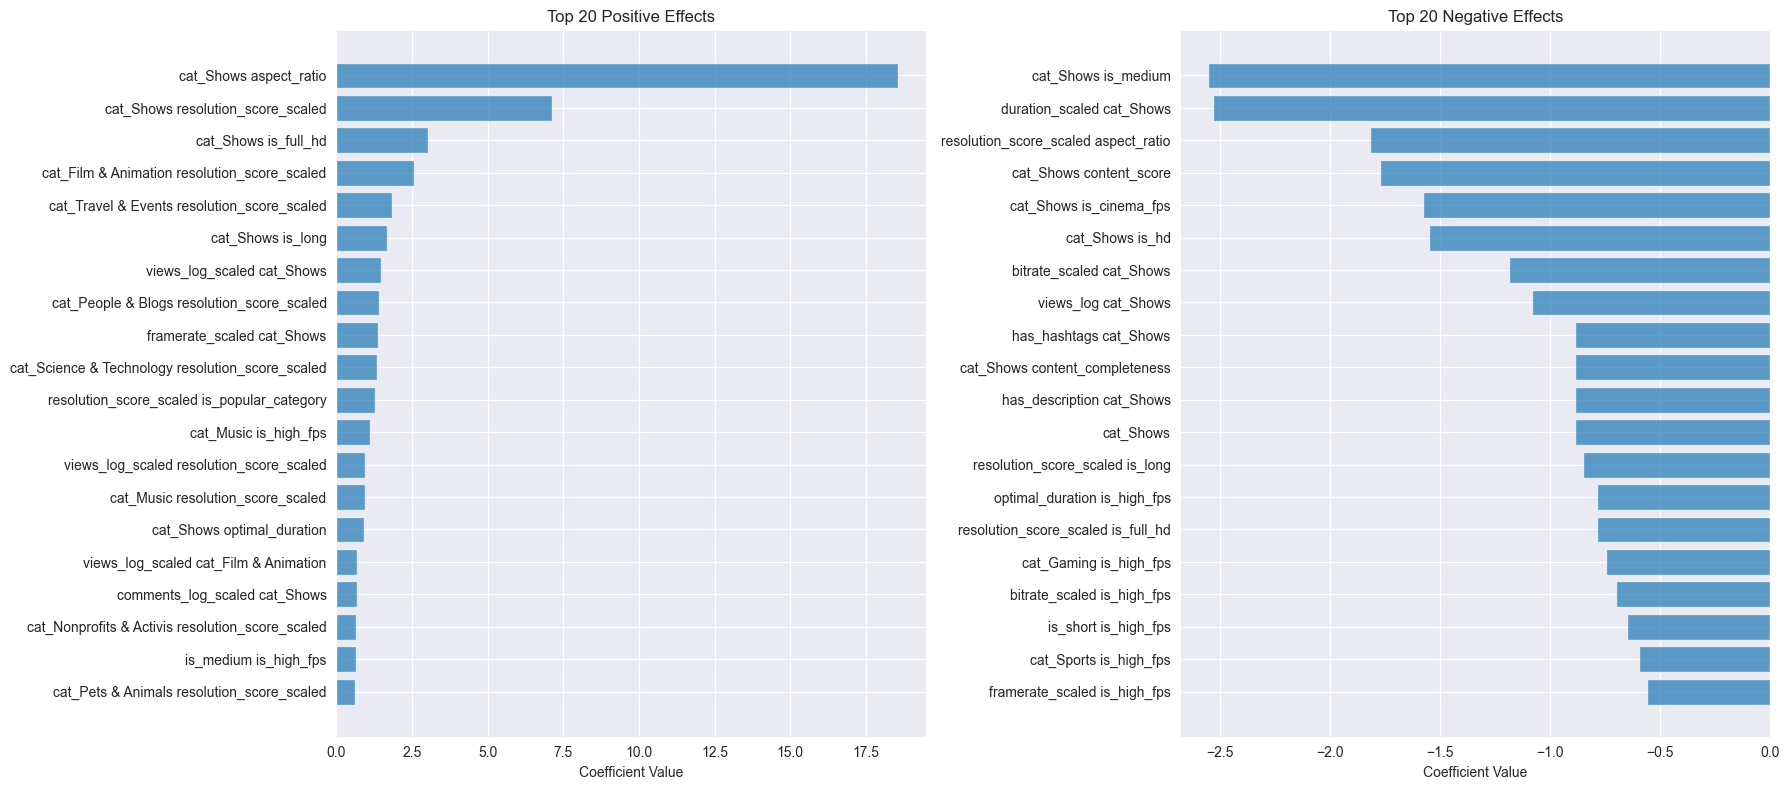

In [25]:
feature_importance_poly2 = analyze_feature_importance(
    pipeline2,
    X_train,
    top_n=20
)

Metric                              Train                 Test
----------------------------------------------------------------------
R² Score                           0.5927               0.9285
MSE                         27,009,424.99         6,815,058.31
RMSE                             5,197.06             2,610.57
MAE                                103.89               111.80

Overfit (R² diff)                 -0.3357
   ⚠️ Model có dấu hiệu underfit


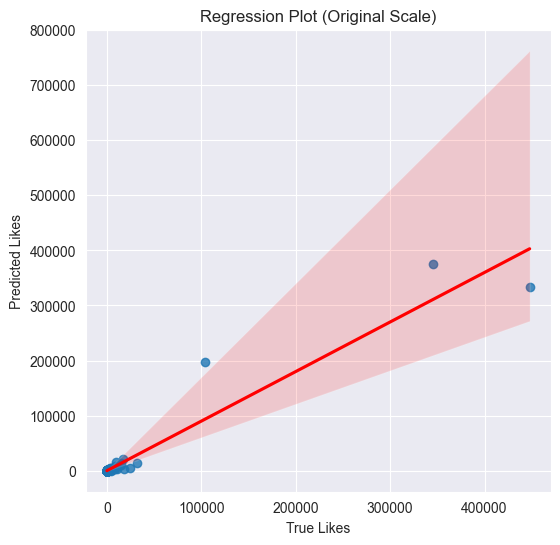

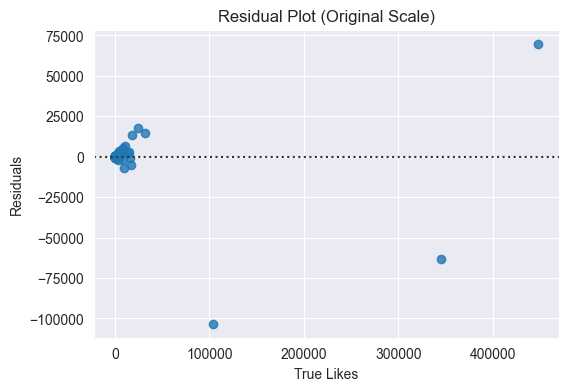

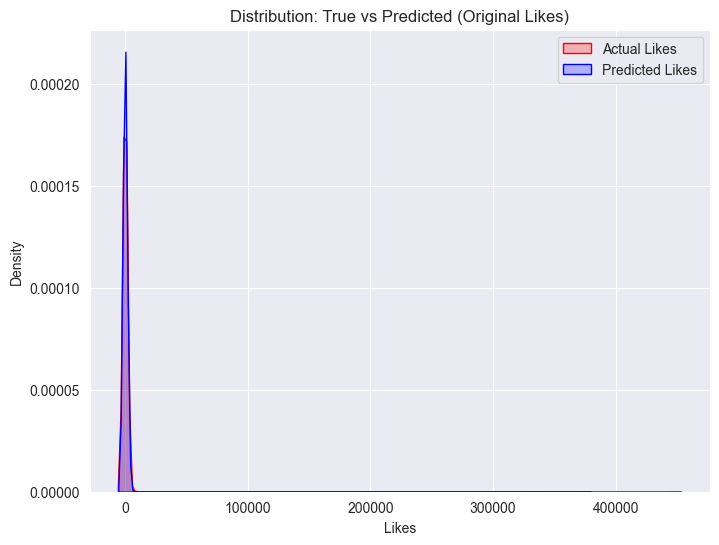

In [26]:
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

r2_train_orig = r2_score(y_train_orig, y_train_pred_orig)
r2_test_orig = r2_score(y_test_orig, y_test_pred_orig)
mse_train_orig = mean_squared_error(y_train_orig, y_train_pred_orig)
mse_test_orig = mean_squared_error(y_test_orig, y_test_pred_orig)
mae_train_orig = mean_absolute_error(y_train_orig, y_train_pred_orig)
mae_test_orig = mean_absolute_error(y_test_orig, y_test_pred_orig)

print(f"{'Metric':<20s} {'Train':>20s} {'Test':>20s}")
print("-" * 70)
print(f"{'R² Score':<20s} {r2_train_orig:>20.4f} {r2_test_orig:>20.4f}")
print(f"{'MSE':<20s} {mse_train_orig:>20,.2f} {mse_test_orig:>20,.2f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_orig):>20,.2f} {np.sqrt(mse_test_orig):>20,.2f}")
print(f"{'MAE':<20s} {mae_train_orig:>20,.2f} {mae_test_orig:>20,.2f}")

overfit = r2_train_orig - r2_test_orig
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>20.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

y_true_orig = y_test_orig
y_pred_orig = y_test_pred_orig
residuals_orig = y_true_orig - y_pred_orig

# ----- 1. Regression plot (Original Scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true_orig, y=y_pred_orig, line_kws={'color':'red'})
plt.xlabel("True Likes")
plt.ylabel("Predicted Likes")
plt.title("Regression Plot (Original Scale)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

# ----- 2. Residual plot (Original Scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true_orig, y=residuals_orig, line_kws={'color':'red'})
plt.xlabel("True Likes")
plt.ylabel("Residuals")
plt.title("Residual Plot (Original Scale)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

# ----- 3. Distribution comparison (Original Scale) -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true_orig, color='red', label='Actual Likes', shade=True)
sns.kdeplot(y_pred_orig, color='blue', label='Predicted Likes', shade=True)
plt.title('Distribution: True vs Predicted (Original Likes)')
plt.xlabel('Likes')
plt.ylabel('Density')
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()